# Bird Species Classifier — Transfer Learning (EfficientNetV2-S)

This project implements a high-performance deep learning model for bird species classification, capable of identifying 220+ bird species from images. The model is built on an ImageNet-pretrained EfficientNetV2-S backbone and fine-tuned using transfer learning to achieve high classification accuracy while maintaining efficient inference.

## Step 1 : Imports

In [ ]:
import os, json, time, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


## Step 2 : Unzipping DataSet File

In [ ]:
from google.colab import files
uploaded = files.upload()   # picking up Dataset.zip from your PC

import zipfile
zip_path = list(uploaded.keys())[0]
extract_to = "/content/Dataset_extracted"
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_to)
print("Extracted to:", extract_to)

Saving Dataset.zip to Dataset.zip
Extracted to: /content/Dataset_extracted


## Step 3 : Config

In [ ]:
DATA_DIR = "/content/Dataset_extracted"
OUTPUT_DIR = "./output"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_HEAD = 5
EPOCHS_FINETUNE = 25
LR_HEAD = 1e-3
LR_FINETUNE = 1e-4
PATIENCE = 6
NUM_WORKERS = 4
SEED = 42

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SPLIT_NAMES = {"train", "training", "valid", "val", "validation", "test", "testing"}

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}" + ("" if device.type == "cuda" else
      "  (no GPU found — this will be slow; consider Colab/Kaggle GPU runtime)"))


Device: cuda


## Step 4 : Dataset auto-discovery


In [ ]:
def find_class_dirs(root: Path):
    '''Return {class_dir_path: [image_paths]} for directories that directly
    contain image files (i.e. leaf 'species' folders).'''
    result = {}
    for dirpath, dirnames, filenames in os.walk(root):
        imgs = [f for f in filenames if Path(f).suffix.lower() in IMG_EXTS]
        if imgs:
            result[Path(dirpath)] = [Path(dirpath) / f for f in imgs]
    return result


The pipeline automatically detects the dataset structure, identifies bird species folders, and indexes all images. Any existing train, validation, or test folders are ignored if they contain inconsistent class distributions. Instead, all images are combined into a single dataset and split into new stratified train, validation, and test sets for balanced and reliable model evaluation.

In [ ]:
def discover_dataset(data_dir: str):
    root = Path(data_dir)
    if not root.exists():
        raise FileNotFoundError(f"DATA_DIR does not exist: {root}")

    class_dirs = find_class_dirs(root)
    if not class_dirs:
        raise RuntimeError(
            f"No images found anywhere under {root}. "
            f"Top-level contents: {[p.name for p in root.iterdir()]}"
        )

    records = []
    split_membership = defaultdict(set)

    for class_dir, img_paths in class_dirs.items():
        class_name = class_dir.name
        split_name = None
        for ancestor in class_dir.parents:
            if ancestor.name.lower() in SPLIT_NAMES:
                split_name = ancestor.name.lower()
                break
        if split_name:
            split_membership[split_name].add(class_name)
        for p in img_paths:
            records.append({"path": str(p), "label": class_name})

    df = pd.DataFrame(records)

    if split_membership:
        all_class_sets = list(split_membership.values())
        if not all(s == all_class_sets[0] for s in all_class_sets):
            sizes = {k: len(v) for k, v in split_membership.items()}
            print(f"  WARNING: pre-existing split folders {sizes} don't contain "
                  "the same classes. Pooling everything and re-splitting ourselves.")
        else:
            print(f"  Found consistent pre-existing splits {list(split_membership.keys())} "
                  "— pooling anyway for a clean, controlled split ratio.")

    print(f"  Discovered {df['label'].nunique()} classes, {len(df)} images total.")
    return df

df = discover_dataset(DATA_DIR)
df.head()


  Found consistent pre-existing splits ['train', 'test'] — pooling anyway for a clean, controlled split ratio.
  Discovered 200 classes, 11788 images total.


,path,label
0,/content/Dataset_extracted/Train/Common_Tern/C...,Common_Tern
1,/content/Dataset_extracted/Train/Common_Tern/C...,Common_Tern
2,/content/Dataset_extracted/Train/Common_Tern/C...,Common_Tern
3,/content/Dataset_extracted/Train/Common_Tern/C...,Common_Tern
4,/content/Dataset_extracted/Train/Common_Tern/C...,Common_Tern


## Step 5 : Build class index & stratified 70/15/15 split

Each bird species is mapped to a unique integer label for model training. Classes with fewer than three images are excluded to ensure valid dataset splits. The remaining images are divided into stratified train, validation, and test sets, guaranteeing balanced representation of every species and enabling reliable model evaluation.

In [ ]:
classes = sorted(df["label"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["label_idx"] = df["label"].map(class_to_idx)
num_classes = len(classes)

with open(f"{OUTPUT_DIR}/class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=2)

counts = df["label_idx"].value_counts()
too_few = counts[counts < 3]
if len(too_few):
    print(f"  Dropping {len(too_few)} classes with <3 images: "
          f"{[idx_to_class[i] for i in too_few.index]}")
    df = df[~df["label_idx"].isin(too_few.index)]

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label_idx"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label_idx"], random_state=SEED)

print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}  classes={num_classes}")

pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="val"),
    test_df.assign(split="test"),
]).to_csv(f"{OUTPUT_DIR}/train_val_split.csv", index=False)


train=8251  val=1768  test=1769  classes=200


## Step 6 : Dataset class & augmentation

BirdDataset loads images from their file paths and applies preprocessing transforms. Training images undergo extensive augmentation—including random crops, flips, rotations, color jitter, and random erasing—to improve generalization and reduce overfitting. Validation and test images are only resized and normalized to ensure unbiased performance evaluation.

In [ ]:
class BirdDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["path"].tolist()
        self.labels = df["label_idx"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.15),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = BirdDataset(train_df, train_tfms)
val_ds   = BirdDataset(val_df, eval_tfms)
test_ds  = BirdDataset(test_df, eval_tfms)


## Step 7 : Weighted sampler & data loaders


In [ ]:
class_counts = train_df["label_idx"].value_counts().sort_index()
weights_per_class = 1.0 / class_counts
sample_weights = train_df["label_idx"].map(weights_per_class).values
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Step 8 : Model

The model uses an ImageNet-pretrained EfficientNetV2-S backbone for powerful feature extraction. Its original classification head is replaced with a custom Dropout → Linear layer, automatically configured to predict the number of bird species detected in the dataset.

In [ ]:
def build_model(num_classes):
    weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
    model = efficientnet_v2_s(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

model = build_model(num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
checkpoint_path = f"{OUTPUT_DIR}/best_model.pt"
print(sum(p.numel() for p in model.parameters() if p.requires_grad), "trainable params")


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 158MB/s]


20433688 trainable params


## Step 9 : Training utilities


In [ ]:
class EarlyStopper:
    def __init__(self, patience, path):
        self.patience = patience
        self.best_acc = -1
        self.counter = 0
        self.path = path

    def step(self, val_acc, model):
        improved = val_acc > self.best_acc
        if improved:
            self.best_acc = val_acc
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
        return self.counter >= self.patience, improved


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    use_amp = device.type == "cuda"

    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total_n += imgs.size(0)
    return total_loss / total_n, total_correct / total_n


def fit(model, train_loader, val_loader, optimizer, scheduler, epochs, patience, tag=""):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    stopper = EarlyStopper(patience, checkpoint_path)
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, None)
        if scheduler is not None:
            scheduler.step()

        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

        stop, improved = stopper.step(va_acc, model)
        marker = " *saved*" if improved else ""
        print(f"[{tag}] epoch {epoch:02d}/{epochs}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}  ({time.time()-t0:.1f}s){marker}")
        if stop:
            print(f"Early stopping at epoch {epoch} (best val_acc={stopper.best_acc:.4f})")
            break
    return history, stopper.best_acc


## Step 9 : Phase 1 — train the classifier head only


In [ ]:
for name, param in model.named_parameters():
    param.requires_grad = name.startswith("classifier")

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_HEAD)

history_head, _ = fit(model, train_loader, val_loader, optimizer, scheduler,
                       epochs=EPOCHS_HEAD, patience=EPOCHS_HEAD + 1, tag="head")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[head] epoch 01/5  train_loss=4.1944 train_acc=0.2137  val_loss=3.4658 val_acc=0.3247  (112.9s) *saved*
[head] epoch 02/5  train_loss=3.1987 train_acc=0.3928  val_loss=3.0660 val_acc=0.4010  (102.1s) *saved*
[head] epoch 03/5  train_loss=2.9016 train_acc=0.4678  val_loss=2.9165 val_acc=0.4236  (102.0s) *saved*
[head] epoch 04/5  train_loss=2.7780 train_acc=0.4915  val_loss=2.8281 val_acc=0.4491  (102.1s) *saved*
[head] epoch 05/5  train_loss=2.7387 train_acc=0.5062  val_loss=2.8376 val_acc=0.4593  (104.4s) *saved*


## Step 9 : Phase 2 — fine-tune the whole network

After training the classifier head, the entire EfficientNetV2-S backbone is unfrozen and fine-tuned using a lower learning rate with Cosine Learning Rate Scheduling. Early stopping based on validation accuracy prevents overfitting, and the best-performing model checkpoint is automatically restored for final evaluation.

In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FINETUNE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_FINETUNE)

history_ft, best_val_acc = fit(model, train_loader, val_loader, optimizer, scheduler,
                                epochs=EPOCHS_FINETUNE, patience=PATIENCE, tag="finetune")

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"Loaded best checkpoint (val_acc={best_val_acc:.4f}).")


[finetune] epoch 01/25  train_loss=2.0070 train_acc=0.7077  val_loss=1.8502 val_acc=0.7308  (123.1s) *saved*
[finetune] epoch 02/25  train_loss=1.6181 train_acc=0.8271  val_loss=1.7348 val_acc=0.7551  (115.2s) *saved*
[finetune] epoch 03/25  train_loss=1.4520 train_acc=0.8840  val_loss=1.6645 val_acc=0.7771  (112.3s) *saved*
[finetune] epoch 04/25  train_loss=1.3435 train_acc=0.9114  val_loss=1.5928 val_acc=0.8083  (115.2s) *saved*
[finetune] epoch 05/25  train_loss=1.2709 train_acc=0.9338  val_loss=1.5782 val_acc=0.8083  (115.7s)
[finetune] epoch 06/25  train_loss=1.2259 train_acc=0.9434  val_loss=1.5487 val_acc=0.8150  (115.3s) *saved*
[finetune] epoch 07/25  train_loss=1.1632 train_acc=0.9610  val_loss=1.5331 val_acc=0.8156  (115.8s) *saved*
[finetune] epoch 08/25  train_loss=1.1336 train_acc=0.9657  val_loss=1.5240 val_acc=0.8201  (114.4s) *saved*
[finetune] epoch 09/25  train_loss=1.1053 train_acc=0.9722  val_loss=1.4935 val_acc=0.8343  (114.8s) *saved*
[finetune] epoch 10/25  tra

## Step 10 : Training curves

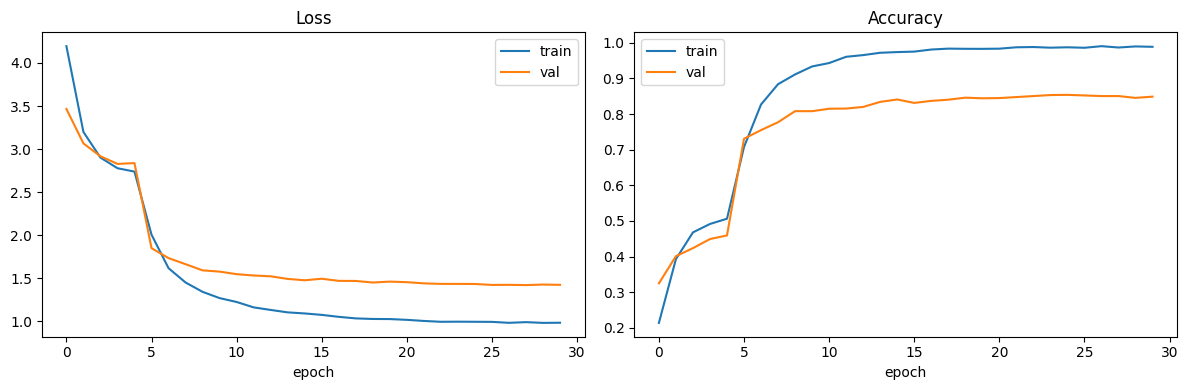

In [ ]:
def concat(key):
    return history_head[key] + history_ft[key]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(concat("train_loss"), label="train"); ax[0].plot(concat("val_loss"), label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(concat("train_acc"), label="train"); ax[1].plot(concat("val_acc"), label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150); plt.show()


## Step 11 : Final evaluation on the held-out test set

The model is evaluated using overall accuracy and a per-class Precision, Recall, and F1-score report. These metrics help identify bird species with lower performance, which often correspond to visually similar species that are more difficult for the model to distinguish.

In [ ]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=classes, digits=3, zero_division=0)
print(f"Test accuracy: {test_acc:.4f}\n")
print(report)

with open(f"{OUTPUT_DIR}/classification_report.txt", "w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\n\n{report}")


Test accuracy: 0.8440

                                precision    recall  f1-score   support

            Acadian_Flycatcher      0.625     0.556     0.588         9
                 American_Crow      0.500     0.778     0.609         9
            American_Goldfinch      0.750     0.667     0.706         9
                American_Pipit      0.889     0.889     0.889         9
             American_Redstart      1.000     0.889     0.941         9
American_Three_toed_Woodpecker      1.000     0.857     0.923         7
              Anna_Hummingbird      0.857     0.667     0.750         9
                    Artic_Tern      0.833     0.556     0.667         9
                 Baird_Sparrow      0.667     0.571     0.615         7
              Baltimore_Oriole      0.900     1.000     0.947         9
                  Bank_Swallow      0.727     0.889     0.800         9
                  Barn_Swallow      0.750     0.667     0.706         9
          Bay_breasted_Warbler      1.00

## Step 12 : Analyzing Using Confusion Matrix

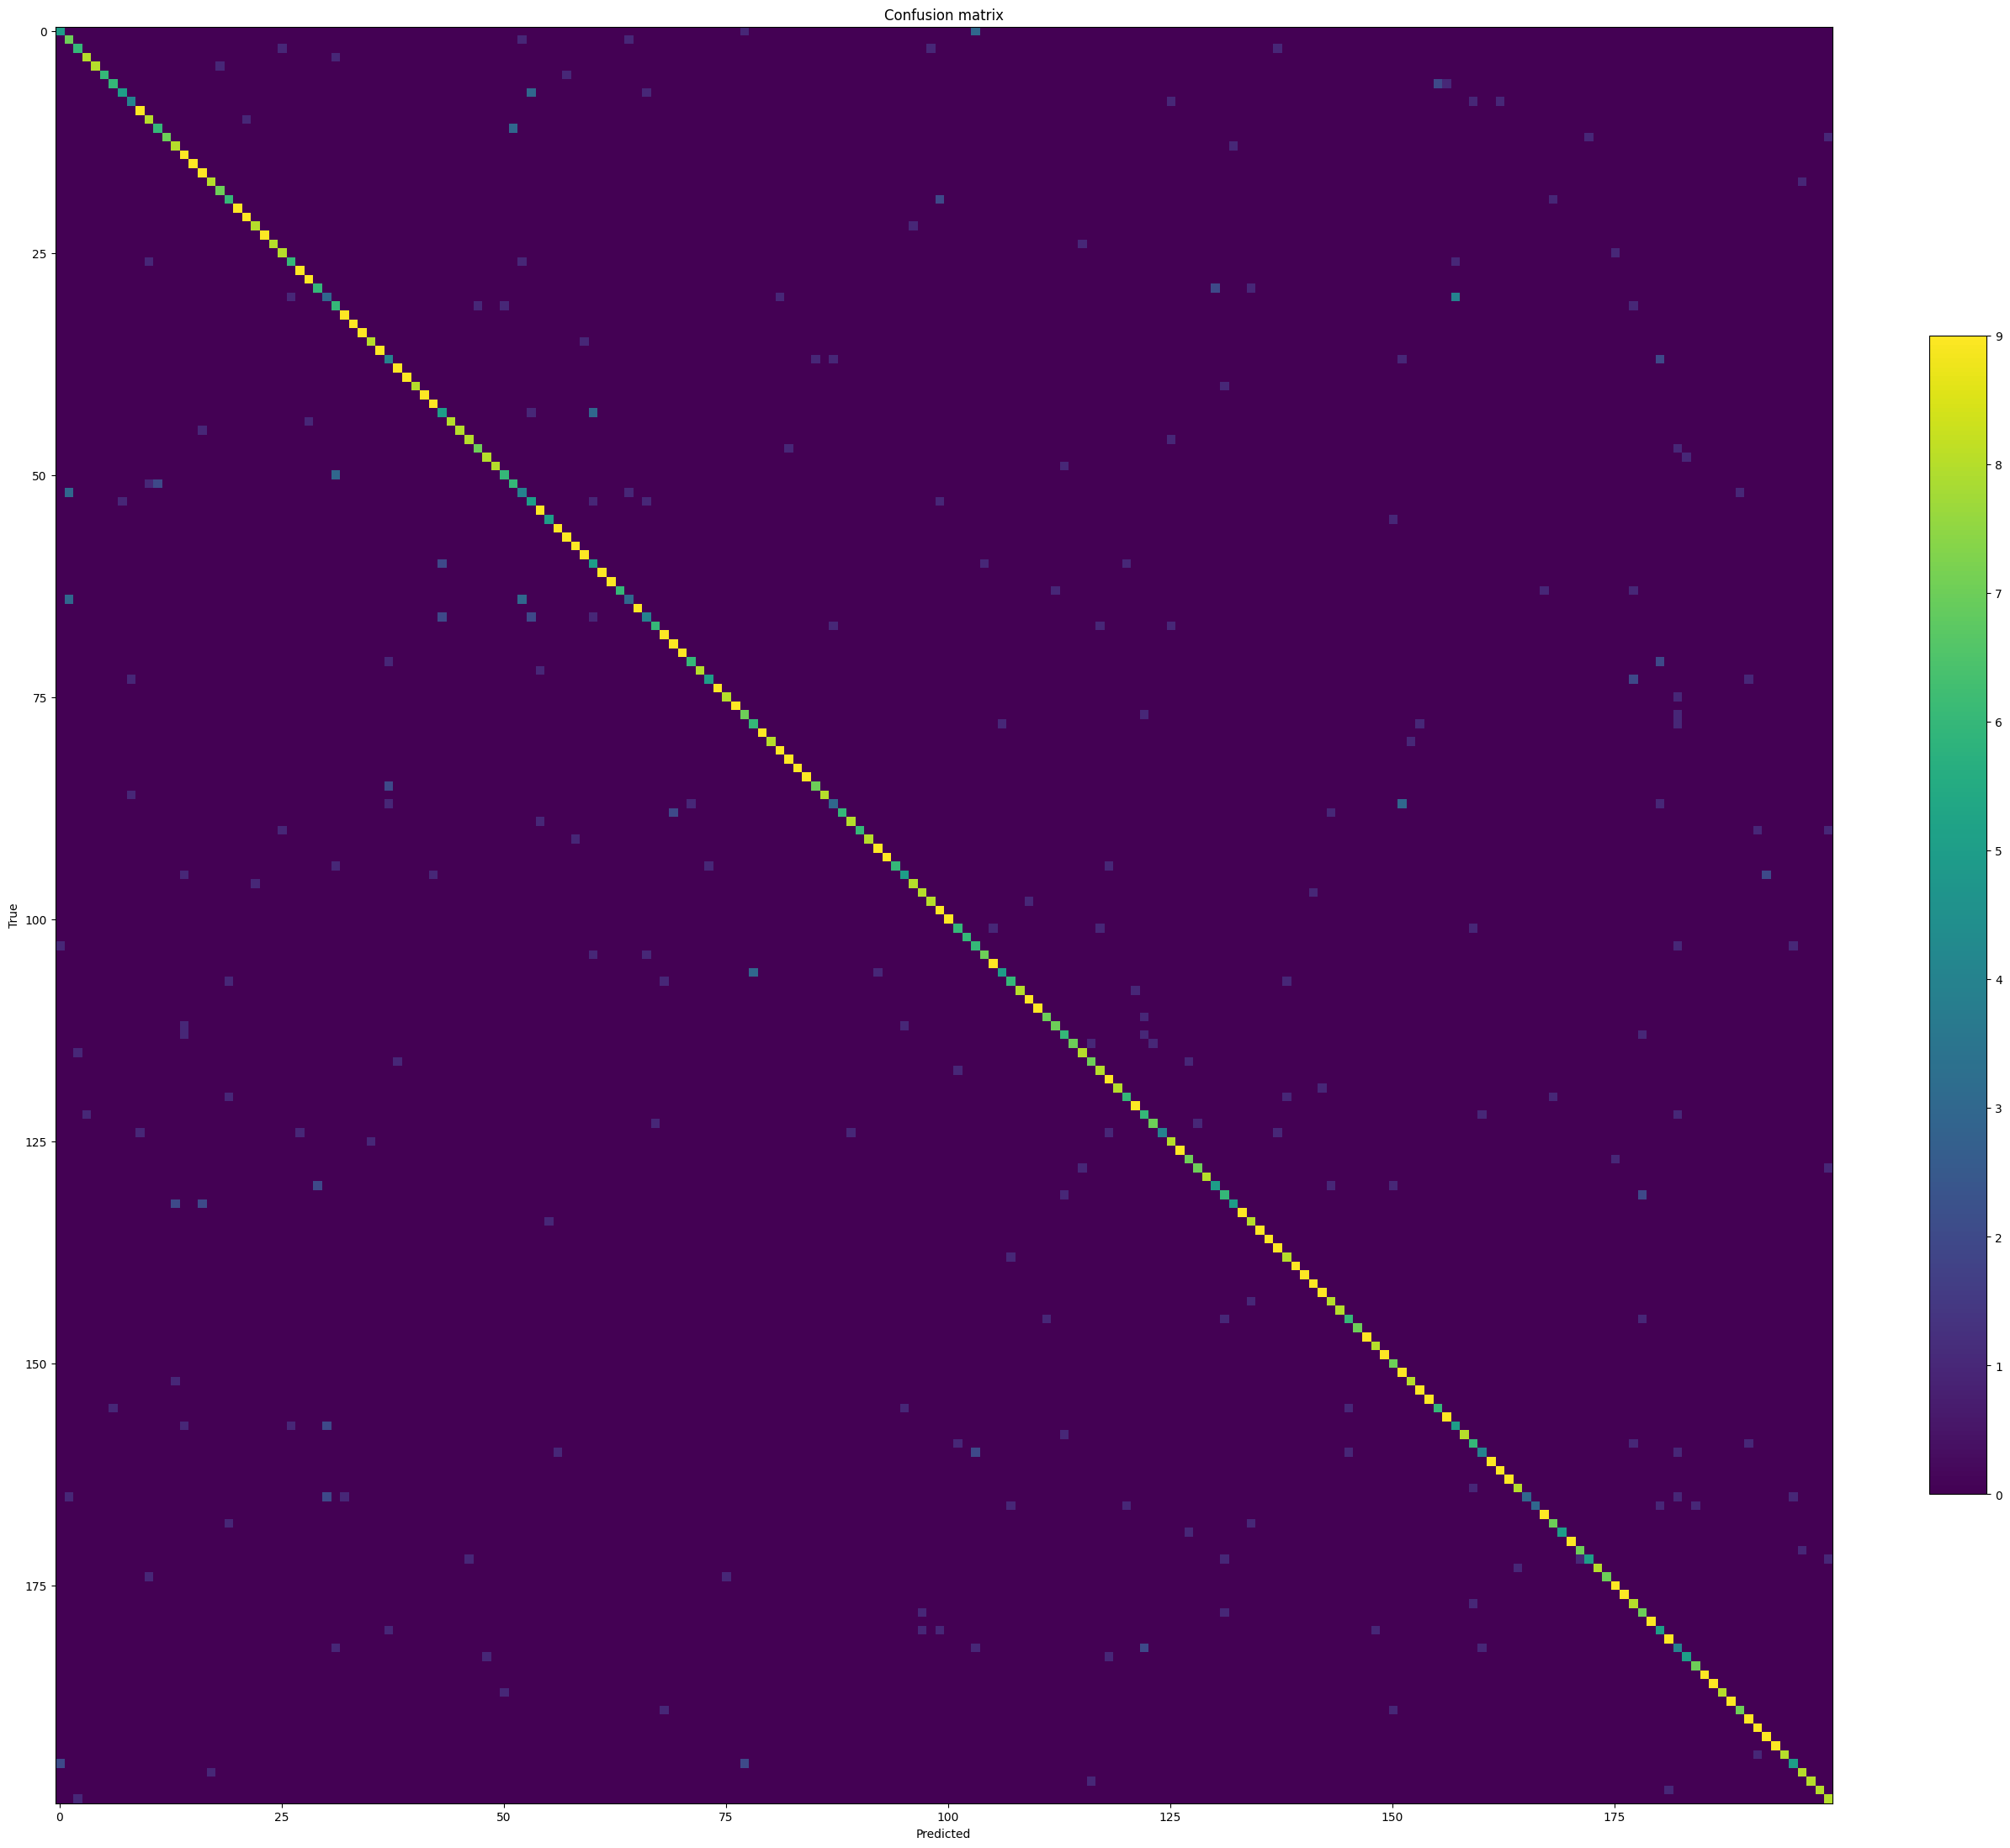

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig_size = max(10, num_classes * 0.12)
plt.figure(figsize=(fig_size, fig_size))
plt.imshow(cm, cmap="viridis")
plt.title("Confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.colorbar(fraction=0.03)
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150); plt.show()


## Step 13 : Save the final model

In [ ]:
final_path = f"{OUTPUT_DIR}/bird_classifier_effnetv2s.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "img_size": IMG_SIZE,
    "mean": IMAGENET_MEAN,
    "std": IMAGENET_STD,
    "test_accuracy": test_acc,
}, final_path)
print(f"Saved final model to {final_path}")


Saved final model to ./output/bird_classifier_effnetv2s.pt
